In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import pandas as pd

x_train = pd.read_csv('x_train_final.csv')
y_train = pd.read_csv('y_train_final.csv')
x_test  = pd.read_csv('x_test_final.csv')

print(f"\nx_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")


x_train: (667264, 12)
y_train: (667264, 2)
x_test: (20657, 11)


In [2]:
# EDA
print("=== X_TRAIN ===")
print(f"Shape: {x_train.shape}")
print(f"Colonnes: {list(x_train.columns)}")
print(f"\nTypes:\n{x_train.dtypes}")
print(f"\nValeurs uniques:")
for col in x_train.columns:
    print(f"  {col}: {x_train[col].nunique()}")
print(f"\n{x_train.head()}")
print(f"\n{x_train.describe()}")

print("\n=== Y_TRAIN ===")
print(f"Shape: {y_train.shape}")
print(f"\n{y_train.describe()}")

print("\n=== X_TEST ===")
print(f"Shape: {x_test.shape}")
print(f"\n{x_test.head()}")

=== X_TRAIN ===
Shape: (667264, 12)
Colonnes: ['Unnamed: 0.1', 'Unnamed: 0', 'train', 'gare', 'date', 'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']

Types:
Unnamed: 0.1      int64
Unnamed: 0        int64
train               str
gare                str
date                str
arret             int64
p2q0            float64
p3q0            float64
p4q0            float64
p0q2            float64
p0q3            float64
p0q4            float64
dtype: object

Valeurs uniques:
  Unnamed: 0.1: 667264
  Unnamed: 0: 667264
  train: 37544
  gare: 84
  date: 91
  arret: 36
  p2q0: 120
  p3q0: 123
  p4q0: 121
  p0q2: 121
  p0q3: 123
  p0q4: 123

   Unnamed: 0.1  Unnamed: 0   train gare        date  arret  p2q0  p3q0  p4q0  \
0             0           0  VBXNMF  KYF  2023-04-03      8   0.0   0.0   1.0   
1             1           1  VBXNMF  JLR  2023-04-03      9   0.0   0.0   0.0   
2             2           2  VBXNMF  EOH  2023-04-03     10  -1.0   0.0   0.0   
3             3        

In [3]:
y = y_train["p0q0"]
print(f"y: {y.shape}")
print(f"\n{y.describe()}")

y: (667264,)

count    667264.000000
mean         -0.159950
std           1.987872
min        -160.000000
25%          -1.000000
50%           0.000000
75%           1.000000
max          15.000000
Name: p0q0, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import copy
from sklearn.preprocessing import LabelEncoder

# ===== Concat train + test pour features communes =====
full = pd.concat([x_train, x_test], axis=0).reset_index(drop=True)
full = full.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], errors="ignore")

full["date"] = pd.to_datetime(full["date"])

# ===== FEATURE TEMPORELLE : jour de la semaine =====
full["day_of_week"] = full["date"].dt.dayofweek  # 0=lundi, 6=dimanche

# ===== FEATURE ENGINEERING (même logique que le pote) =====
cols_retard_train = ["p2q0", "p3q0", "p4q0"]
cols_retard_gare  = ["p0q2", "p0q3", "p0q4"]
cols_all = cols_retard_train + cols_retard_gare

# Moyennes et écart-types
full["mean_retard_train"]  = full[cols_retard_train].mean(axis=1)
full["mean_retard_gare"]   = full[cols_retard_gare].mean(axis=1)
full["mean_retard_global"] = full[cols_all].mean(axis=1)
full["std_retard_train"]   = full[cols_retard_train].std(axis=1)
full["std_retard_gare"]    = full[cols_retard_gare].std(axis=1)

# Tendances
full["tendance_train"] = full["p2q0"] - full["p4q0"]
full["tendance_gare"]  = full["p0q2"] - full["p0q4"]

# Extrêmes
full["max_retard"] = full[cols_all].max(axis=1)
full["min_retard"] = full[cols_all].min(axis=1)

# ===== Position moyenne de la gare dans le trajet =====
train_part = full.iloc[:len(y)]
position_gare = {}
for (train_id, date), groupe in train_part.groupby(["train", "date"]):
    groupe = groupe.sort_values("arret")
    n = len(groupe)
    for i, (_, row) in enumerate(groupe.iterrows()):
        gare = row["gare"]
        position_gare.setdefault(gare, []).append(i / (n - 1) if n > 1 else 0)

position_df = pd.DataFrame({
    "gare": list(position_gare.keys()),
    "position_moyenne": [np.mean(v) for v in position_gare.values()]
})
full = full.merge(position_df, on="gare", how="left")
full["position_moyenne"] = full["position_moyenne"].fillna(0)

# ===== Fréquence de trains par jour par gare =====
freq_gare = train_part.groupby(["gare", "date"])["train"].nunique().groupby("gare").mean().reset_index()
freq_gare.columns = ["gare", "freq_trains_par_jour"]
full = full.merge(freq_gare, on="gare", how="left")
full["freq_trains_par_jour"] = full["freq_trains_par_jour"].fillna(0)

# ===== DIGRAPH DU PROF : sous-graphes par jour, edges consécutifs uniquement =====
print("Construction du DiGraph (code du prof)...")
sub_graphs = {}

for day, group_day in train_part.groupby("date"):
    sub_G = nx.DiGraph()
    for _, group_train in group_day.groupby("train"):
        group_train = group_train.sort_values("arret")
        gares  = group_train["gare"].values
        stops  = group_train["arret"].values
        delays = group_train["p2q0"].values
        delays_s2 = group_train["p0q2"].values

        edges = [(gares[i], gares[i+1]) for i in range(len(gares) - 1) if stops[i+1] == stops[i] + 1]
        sub_G.add_edges_from(edges)

        for i in range(len(edges)):
            try:
                delay = sub_G.edges[edges[i]]["delay"]
                count = sub_G.edges[edges[i]]["count"]
                delay_s2 = sub_G.edges[edges[i]]["delay_s2"]
                nx.set_edge_attributes(sub_G, {edges[i]: {
                    "delay": delay + delays[i+1],
                    "count": count + 1,
                    "delay_s2": delay_s2 + delays_s2[i+1]
                }})
            except:
                nx.set_edge_attributes(sub_G, {edges[i]: {
                    "delay": delays[i+1],
                    "count": 1,
                    "delay_s2": delays_s2[i+1]
                }})
    sub_graphs[str(day.date())] = copy.deepcopy(sub_G)

G = nx.DiGraph()
for g in sub_graphs.values():
    G = nx.compose(G, g)

edge_data = {}
for e in G.edges:
    edge_data[e] = {"delay": 0, "count": 0, "delay_s2": 0}
    for g in sub_graphs.values():
        if e in g.edges:
            edge_data[e]["delay"] += g.edges[e]["delay"]
            edge_data[e]["count"] += g.edges[e]["count"]
            edge_data[e]["delay_s2"] += g.edges[e]["delay_s2"]

nx.set_edge_attributes(G, edge_data)
del edge_data

print(f"DiGraph: {G.number_of_nodes()} gares, {G.number_of_edges()} arcs")

for u, v, d in G.edges(data=True):
    d["mean_delay"] = d["delay"] / d["count"] if d["count"] > 0 else 0
    d["mean_delay_s2"] = d["delay_s2"] / d["count"] if d["count"] > 0 else 0

gare_in_delay = {}
gare_out_delay = {}
gare_in_delay_s2 = {}
gare_out_count = {}

for node in G.nodes():
    in_edges = [(u, v, d) for u, v, d in G.in_edges(node, data=True)]
    out_edges = [(u, v, d) for u, v, d in G.out_edges(node, data=True)]

    gare_in_delay[node] = np.mean([d["mean_delay"] for _, _, d in in_edges]) if in_edges else 0
    gare_out_delay[node] = np.mean([d["mean_delay"] for _, _, d in out_edges]) if out_edges else 0
    gare_in_delay_s2[node] = np.mean([d["mean_delay_s2"] for _, _, d in in_edges]) if in_edges else 0
    gare_out_count[node] = sum(d["count"] for _, _, d in out_edges)

pagerank = nx.pagerank(G, weight="count", max_iter=200)

full["gare_retard_entrant"]     = full["gare"].map(gare_in_delay).fillna(0)
full["gare_retard_sortant"]     = full["gare"].map(gare_out_delay).fillna(0)
full["gare_retard_entrant_s2"]  = full["gare"].map(gare_in_delay_s2).fillna(0)
full["gare_trafic_sortant"]     = full["gare"].map(gare_out_count).fillna(0)
full["gare_pagerank"]           = full["gare"].map(pagerank).fillna(0)

full_sorted = full.sort_values(["train", "date", "arret"]).reset_index(drop=True)
full_sorted["gare_prev"] = full_sorted.groupby(["train", "date"])["gare"].shift(1)
full["gare_prev"] = full_sorted["gare_prev"]

edge_mean_map = {(u, v): d["mean_delay"] for u, v, d in G.edges(data=True)}
full["edge_mean_retard"] = full.apply(
    lambda r: edge_mean_map.get((r["gare_prev"], r["gare"]), np.nan) if pd.notna(r["gare_prev"]) else np.nan, axis=1
)
global_mean_delay = np.mean([d["mean_delay"] for _, _, d in G.edges(data=True)])
full["edge_mean_retard"] = full["edge_mean_retard"].fillna(global_mean_delay)

full = full.drop(columns=["gare_prev"])

print(f"Features graphe: gare_retard_entrant, gare_retard_sortant, gare_retard_entrant_s2, gare_trafic_sortant, gare_pagerank, edge_mean_retard")

# ===== Label encoding =====
le_train = LabelEncoder()
full["train_enc"] = le_train.fit_transform(full["train"])
le_gare = LabelEncoder()
full["gare_enc"] = le_gare.fit_transform(full["gare"])

_date = full["date"]
_train_str = full["train"]
_gare_str = full["gare"]
full = full.drop(columns=["date"]).fillna(0)
full["date"] = _date
full["train_str"] = _train_str
full["gare_str"] = _gare_str

x_train_fe = full.iloc[:len(y)].copy()
x_test_fe  = full.iloc[len(y):].copy()

print(f"x_train: {x_train_fe.shape}, x_test: {x_test_fe.shape}")
print("Colonnes:", list(x_train_fe.columns))

Construction du DiGraph (code du prof)...
DiGraph: 84 gares, 509 arcs
Features graphe: gare_retard_entrant, gare_retard_sortant, gare_retard_entrant_s2, gare_trafic_sortant, gare_pagerank, edge_mean_retard
x_train: (667264, 32), x_test: (20657, 32)
Colonnes: ['train', 'gare', 'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'day_of_week', 'mean_retard_train', 'mean_retard_gare', 'mean_retard_global', 'std_retard_train', 'std_retard_gare', 'tendance_train', 'tendance_gare', 'max_retard', 'min_retard', 'position_moyenne', 'freq_trains_par_jour', 'gare_retard_entrant', 'gare_retard_sortant', 'gare_retard_entrant_s2', 'gare_trafic_sortant', 'gare_pagerank', 'edge_mean_retard', 'train_enc', 'gare_enc', 'date', 'train_str', 'gare_str']


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def compute_stats_7j(data, group_col, target_col="p0q0"):
    """Rolling 7j sur la target. Pour chaque date, on regarde les 7 jours PRÉCÉDENTS (strict)."""
    records = []
    data = data.copy()
    data["date"] = pd.to_datetime(data["date"])
    for date in sorted(data["date"].unique()):
        date_min = date - pd.Timedelta(days=7)
        fenetre = data[(data["date"] > date_min) & (data["date"] < date)]
        if len(fenetre) == 0:
            continue
        stats = fenetre.groupby(group_col)[target_col].agg(
            **{f"{group_col}_mean_7j": "mean",
               f"{group_col}_std_7j":  "std"}
        ).reset_index()
        stats["date"] = date
        records.append(stats)
    if records:
        return pd.concat(records, ignore_index=True)
    return pd.DataFrame()

def add_target_features(df, x_fit, y_fit):
    """Ajoute les features target-encoded SANS smoothing + rolling 7j.
    Calculées sur (x_fit, y_fit), appliquées à df."""
    result = df.reset_index(drop=True).copy()
    fit = x_fit[["gare_enc", "train_enc", "gare_str", "train_str", "date"]].copy().reset_index(drop=True)
    fit["p0q0"] = y_fit.values

    # --- Target stats par gare (mean, std, median, q25, q75) ---
    stats_gare = fit.groupby("gare_enc")["p0q0"].agg(
        gare_mean="mean", gare_std="std", gare_median="median",
        gare_q25=lambda x: x.quantile(0.25), gare_q75=lambda x: x.quantile(0.75)
    ).reset_index()
    result = result.merge(stats_gare, on="gare_enc", how="left")

    # --- Target stats par train (mean, std, median) ---
    stats_train = fit.groupby("train_enc")["p0q0"].agg(
        train_mean="mean", train_std="std", train_median="median"
    ).reset_index()
    result = result.merge(stats_train, on="train_enc", how="left")

    # --- Rolling 7 jours ---
    result["date"] = pd.to_datetime(result["date"])

    stats_train_7j = compute_stats_7j(fit.rename(columns={"train_enc": "train_enc_"}), "train_enc_", "p0q0")
    stats_gare_7j  = compute_stats_7j(fit.rename(columns={"gare_enc": "gare_enc_"}), "gare_enc_", "p0q0")

    if not stats_train_7j.empty:
        stats_train_7j = stats_train_7j.rename(columns={"train_enc_": "train_enc", "train_enc__mean_7j": "train_mean_7j", "train_enc__std_7j": "train_std_7j"})
        result = result.merge(stats_train_7j, on=["train_enc", "date"], how="left")
    else:
        result["train_mean_7j"] = np.nan
        result["train_std_7j"] = np.nan

    if not stats_gare_7j.empty:
        stats_gare_7j = stats_gare_7j.rename(columns={"gare_enc_": "gare_enc", "gare_enc__mean_7j": "gare_mean_7j", "gare_enc__std_7j": "gare_std_7j"})
        result = result.merge(stats_gare_7j, on=["gare_enc", "date"], how="left")
    else:
        result["gare_mean_7j"] = np.nan
        result["gare_std_7j"] = np.nan

    # Fallback NaN → target mean/std globales
    result["train_mean_7j"] = result["train_mean_7j"].fillna(result["train_mean"])
    result["train_std_7j"]  = result["train_std_7j"].fillna(result["train_std"])
    result["gare_mean_7j"]  = result["gare_mean_7j"].fillna(result["gare_mean"])
    result["gare_std_7j"]   = result["gare_std_7j"].fillna(result["gare_std"])

    result = result.drop(columns=["date", "train_str", "gare_str", "train", "gare"], errors="ignore")
    return result

# ===== FEATURES (35 = retrait de train_median, edge_mean_retard, tendance_gare, train_enc) =====
# Retirées car permutation importance ≤ 0.001 (neutres ou nuisibles)
FEATURES = ["arret", "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4",
            "mean_retard_train", "mean_retard_gare", "mean_retard_global",
            "std_retard_train", "std_retard_gare",
            "tendance_train",
            "max_retard", "min_retard",
            "gare_enc",
            "gare_mean", "gare_std", "gare_median", "gare_q25", "gare_q75",
            "train_mean", "train_std",
            "position_moyenne", "freq_trains_par_jour",
            "day_of_week",
            "train_mean_7j", "train_std_7j",
            "gare_mean_7j", "gare_std_7j",
            "gare_retard_entrant", "gare_retard_sortant",
            "gare_retard_entrant_s2", "gare_trafic_sortant", "gare_pagerank"]

print(f"Features: {len(FEATURES)}")

# 1. Split 90/10
x_tr_raw, x_val_raw, y_tr, y_val = train_test_split(x_train_fe, y, test_size=0.10, random_state=42)

# 2. Target encoding + rolling 7j (calculé UNIQUEMENT sur le train fold)
print("Computing target features (train fold)...")
x_tr = add_target_features(x_tr_raw, x_tr_raw, y_tr)
print("Computing target features (val fold)...")
x_val = add_target_features(x_val_raw, x_tr_raw, y_tr)

# 3. RF (500 arbres)
model = RandomForestRegressor(
    n_estimators=500,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
model.fit(x_tr[FEATURES], y_tr)

# 4. Évaluation
pred_tr = model.predict(x_tr[FEATURES])
pred_val = model.predict(x_val[FEATURES])

mae_tr = mean_absolute_error(y_tr, pred_tr)
mae_val = mean_absolute_error(y_val, pred_val)

print(f"\nMAE train:      {mae_tr:.4f}")
print(f"MAE validation: {mae_val:.4f}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Features: 35
Computing target features (train fold)...
Computing target features (val fold)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.8min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.7s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:   10.1s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:   22.8s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:   26.6s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    1.8s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    7.9s



MAE train:      0.2457
MAE validation: 0.7409
Features (35): ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'mean_retard_train', 'mean_retard_gare', 'mean_retard_global', 'std_retard_train', 'std_retard_gare', 'tendance_train', 'max_retard', 'min_retard', 'gare_enc', 'gare_mean', 'gare_std', 'gare_median', 'gare_q25', 'gare_q75', 'train_mean', 'train_std', 'position_moyenne', 'freq_trains_par_jour', 'day_of_week', 'train_mean_7j', 'train_std_7j', 'gare_mean_7j', 'gare_std_7j', 'gare_retard_entrant', 'gare_retard_sortant', 'gare_retard_entrant_s2', 'gare_trafic_sortant', 'gare_pagerank']


[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    8.3s finished


In [18]:
from sklearn.model_selection import KFold

# Cross-validation 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_maes = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(x_train_fe)):
    x_cv_tr, x_cv_val = x_train_fe.iloc[tr_idx], x_train_fe.iloc[val_idx]
    y_cv_tr, y_cv_val = y.iloc[tr_idx], y.iloc[val_idx]

    print(f"Fold {fold+1}: computing features...")
    x_cv_tr_enc = add_target_features(x_cv_tr, x_cv_tr, y_cv_tr)
    x_cv_val_enc = add_target_features(x_cv_val, x_cv_tr, y_cv_tr)

    model_cv = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    model_cv.fit(x_cv_tr_enc[FEATURES], y_cv_tr)

    mae = mean_absolute_error(y_cv_val, model_cv.predict(x_cv_val_enc[FEATURES]))
    cv_maes.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.4f}")

print(f"\nMAE moyen: {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}")

Fold 1: computing features...
Fold 1: MAE = 0.7522
Fold 2: computing features...
Fold 2: MAE = 0.7597
Fold 3: computing features...
Fold 3: MAE = 0.7578
Fold 4: computing features...
Fold 4: MAE = 0.7450
Fold 5: computing features...
Fold 5: MAE = 0.7615

MAE moyen: 0.7553 ± 0.0060



--- Feature Importance ---
                   feature  importance
28            gare_mean_7j    0.144732
26           train_mean_7j    0.087538
21              train_mean    0.086219
27            train_std_7j    0.064060
22               train_std    0.064050
0                    arret    0.050469
8         mean_retard_gare    0.044388
29             gare_std_7j    0.043995
10        std_retard_train    0.036394
4                     p0q2    0.029460
7        mean_retard_train    0.028935
11         std_retard_gare    0.026301
9       mean_retard_global    0.023207
6                     p0q4    0.020775
16               gare_mean    0.019914
5                     p0q3    0.019652
1                     p2q0    0.018999
15                gare_enc    0.018703
2                     p3q0    0.015647
12          tendance_train    0.015476
3                     p4q0    0.013985
17                gare_std    0.013966
25             day_of_week    0.013788
14              min_retard    0.0134

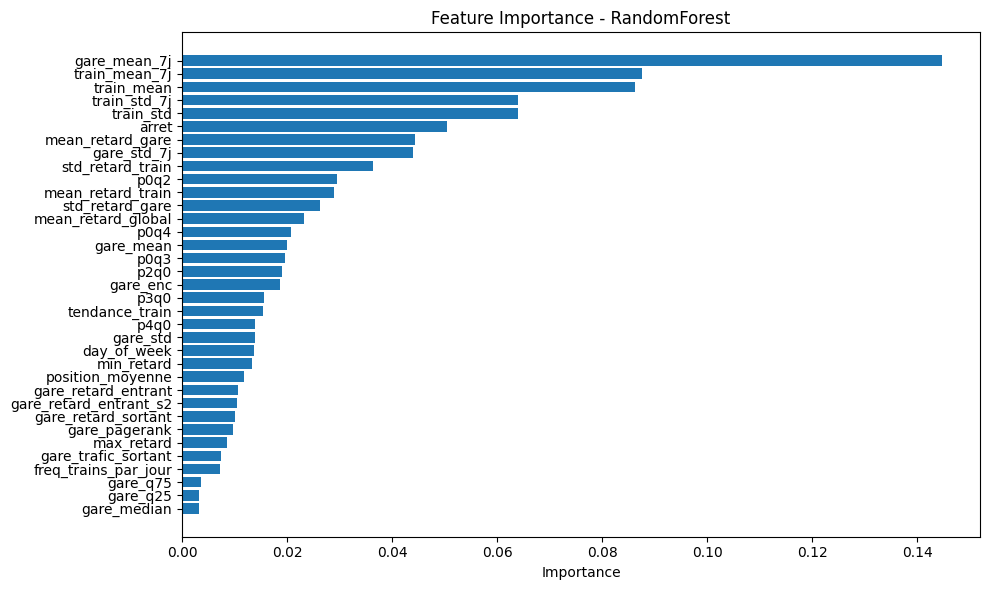

In [19]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Feature Importance ---")
print(feature_importance)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

Permutation importance (RF, MAE validation)...


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    1.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.7s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.9s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.7s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed: 


=== Features qui AIDENT (shuffle → MAE augmente) ===
               feature  importance_mean  importance_std
          gare_mean_7j         0.166708        0.001437
             gare_mean         0.080046        0.000538
                 arret         0.075021        0.000859
                  p2q0         0.044251        0.000546
     mean_retard_train         0.035548        0.000410
          train_std_7j         0.026637        0.000598
             train_std         0.026542        0.000593
      mean_retard_gare         0.014140        0.000343
            train_mean         0.013767        0.000685
         train_mean_7j         0.013539        0.000753
      std_retard_train         0.013110        0.000286
                  p4q0         0.012735        0.000199
              gare_std         0.011543        0.000519
                  p3q0         0.010983        0.000224
           gare_std_7j         0.010131        0.000442
   gare_retard_sortant         0.009241        0.0

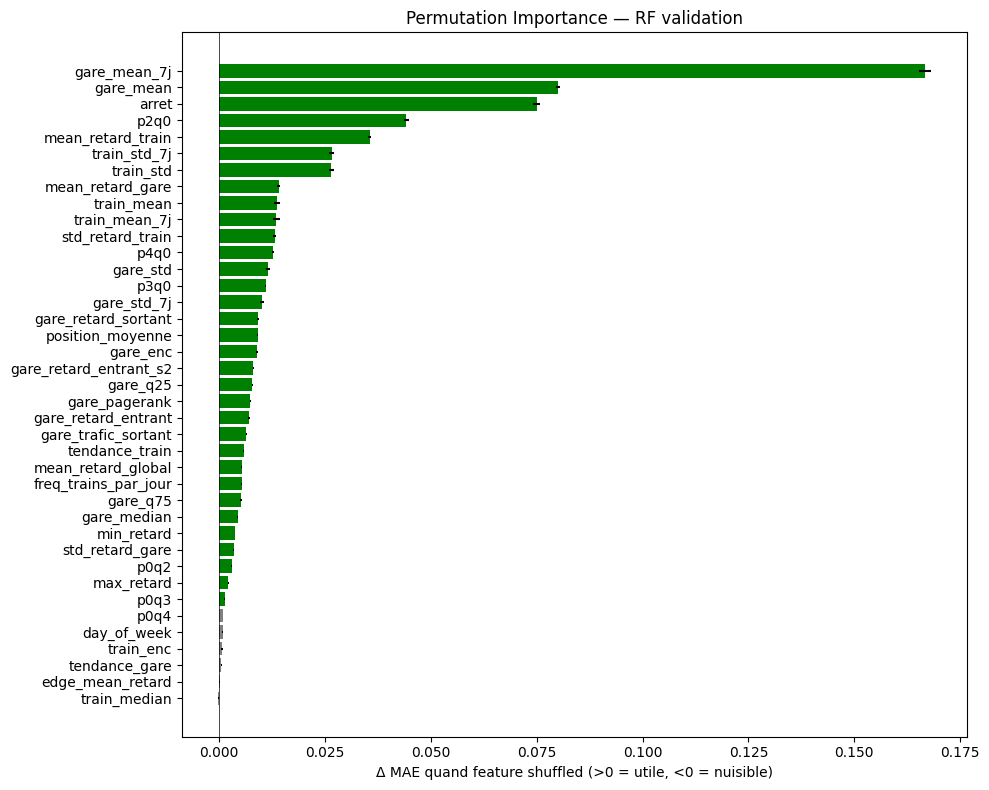


→ Retirer les features rouges/grises pourrait améliorer le score.


In [15]:
# ===== PERMUTATION IMPORTANCE sur MAE validation =====
# Shuffle chaque feature 10 fois, mesure l'impact sur MAE
# Si MAE BAISSE quand on shuffle → la feature NUIT au modèle

from sklearn.inspection import permutation_importance

print("Permutation importance (RF, MAE validation)...")
perm_result = permutation_importance(
    model, x_val[FEATURES], y_val,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

perm_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n=== Features qui AIDENT (shuffle → MAE augmente) ===")
helpful = perm_df[perm_df['importance_mean'] > 0.001]
print(helpful.to_string(index=False))

print("\n=== Features NEUTRES ou NUISIBLES (shuffle → MAE baisse ou stable) ===")
harmful = perm_df[perm_df['importance_mean'] <= 0.001]
print(harmful.to_string(index=False))

# Barplot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if v > 0.001 else ('red' if v < -0.001 else 'gray')
          for v in perm_df['importance_mean']]
ax.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Δ MAE quand feature shuffled (>0 = utile, <0 = nuisible)')
ax.set_title('Permutation Importance — RF validation')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n→ Retirer les features rouges/grises pourrait améliorer le score.")

In [20]:
# Pas de filtrage de features — on garde toutes les features
print(f"Utilisation de {len(FEATURES)} features: {FEATURES}")

Utilisation de 35 features: ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'mean_retard_train', 'mean_retard_gare', 'mean_retard_global', 'std_retard_train', 'std_retard_gare', 'tendance_train', 'max_retard', 'min_retard', 'gare_enc', 'gare_mean', 'gare_std', 'gare_median', 'gare_q25', 'gare_q75', 'train_mean', 'train_std', 'position_moyenne', 'freq_trains_par_jour', 'day_of_week', 'train_mean_7j', 'train_std_7j', 'gare_mean_7j', 'gare_std_7j', 'gare_retard_entrant', 'gare_retard_sortant', 'gare_retard_entrant_s2', 'gare_trafic_sortant', 'gare_pagerank']


In [21]:
# Target encoding + rolling 7j sur TOUT le train, appliqué au train et au test
print("Computing final features...")
x_train_final = add_target_features(x_train_fe, x_train_fe, y)
x_test_final = add_target_features(x_test_fe, x_train_fe, y)

# Modèle final RF (500 arbres, params défaut)
model_final = RandomForestRegressor(
    n_estimators=500,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
model_final.fit(x_train_final[FEATURES], y)

pred_test = model_final.predict(x_test_final[FEATURES])

# Arrondi à l'entier
pred_test_rounded = np.round(pred_test).astype(int)

submission = pd.DataFrame({"p0q0": pred_test_rounded})
submission.to_csv("submission_v17_aligned.csv", index=True)

print(f"submission_v17_aligned.csv créé avec {len(submission)} lignes")
print(submission.head())
print(f"\nStats prédictions:\n{submission.describe()}")

Computing final features...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    3.2s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    3.2s finished


submission_v17_aligned.csv créé avec 20657 lignes
   p0q0
0     0
1     1
2     0
3     0
4    -1

Stats prédictions:
               p0q0
count  20657.000000
mean      -0.070920
std        0.868345
min       -3.000000
25%       -1.000000
50%        0.000000
75%        0.000000
max        3.000000


In [23]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun'}")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [24]:
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler, StandardScaler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} → {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ===== Features NN : retirer les 5 features train_* (NaN 99.99% du test) =====
NN_FEATURES = [f for f in FEATURES if f not in
               ["train_mean", "train_std", "train_median", "train_mean_7j", "train_std_7j"]]
print(f"NN: {len(NN_FEATURES)} features (retirées: train_mean/std/median/7j)")

# ===== Préparer X avec x_tr/x_val =====
X_nn_tr  = x_tr[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
X_nn_val = x_val[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)

scaler_X = RobustScaler()
X_nn_tr  = np.clip(scaler_X.fit_transform(X_nn_tr), -10, 10).astype(np.float32)
X_nn_val = np.clip(scaler_X.transform(X_nn_val), -10, 10).astype(np.float32)

scaler_y = StandardScaler()
y_tr_s = scaler_y.fit_transform(y_tr.values.reshape(-1, 1)).flatten().astype(np.float32)
y_val_s = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten().astype(np.float32)

print(f"y scaled range: [{y_tr_s.min():.1f}, {y_tr_s.max():.1f}]")

# === PyTorch MLP (même arch que Keras : Dense(relu)→BN→Dropout) ===
class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.ReLU(),
            nn.BatchNorm1d(256, momentum=0.01, eps=0.001), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.BatchNorm1d(128, momentum=0.01, eps=0.001), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.BatchNorm1d(64, momentum=0.01, eps=0.001),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_nn(X_train, y_train, X_val, y_val, n_features, seed=42,
             epochs=200, batch_size=1024, patience=30):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)

    model = MLP(n_features).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, eps=1e-7)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=10, min_lr=1e-6)
    loss_fn = nn.HuberLoss(delta=1.0)

    X_tr_t = torch.tensor(X_train, device=device)
    y_tr_t = torch.tensor(y_train, device=device)
    X_val_t = torch.tensor(X_val, device=device)
    y_val_t = torch.tensor(y_val, device=device)
    n_samples = X_tr_t.shape[0]

    best_val_mae, best_state, wait = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_samples, device=device)
        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            pred = model(X_tr_t[idx])
            loss = loss_fn(pred, y_tr_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_mae = (model(X_val_t) - y_val_t).abs().mean().item()

        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, epoch + 1 - patience


# ===== ENSEMBLE DE NN : moyenne de N_SEEDS modèles (GPU) =====
N_SEEDS = 5
nn_models = []
nn_val_preds = []

for seed_i in range(N_SEEDS):
    seed = 42 + seed_i * 7
    print(f"\n--- NN seed {seed} ({seed_i+1}/{N_SEEDS}) ---")

    m, stopped_epoch = train_nn(X_nn_tr, y_tr_s, X_nn_val, y_val_s, len(NN_FEATURES), seed=seed)

    m.eval()
    with torch.no_grad():
        pred_i = m(torch.tensor(X_nn_val, device=device)).cpu().numpy()
    pred_i = scaler_y.inverse_transform(pred_i.reshape(-1, 1)).flatten()
    mae_i = mean_absolute_error(y_val, pred_i)
    print(f"  MAE val: {mae_i:.4f} (stopped ~epoch {stopped_epoch})")
    nn_models.append(m)
    nn_val_preds.append(pred_i)

# Moyenne des prédictions NN
pred_nn_val = np.mean(nn_val_preds, axis=0)
mae_nn = mean_absolute_error(y_val, pred_nn_val)

# RF val
pred_rf_val = model.predict(x_val[FEATURES])
mae_rf = mean_absolute_error(y_val, pred_rf_val)

print(f"\n{'='*50}")
print(f"MAE RF         : {mae_rf:.4f}")
for i, p in enumerate(nn_val_preds):
    print(f"MAE NN seed {i} : {mean_absolute_error(y_val, p):.4f}")
print(f"MAE NN ensemble: {mae_nn:.4f}  ← moyenne de {N_SEEDS} NNs")
print(f"{'='*50}")

# Alpha blend search (pas de 1%)
best_alpha, best_mae = 0, 999
for a in np.arange(0, 1.001, 0.01):
    mix = a * pred_nn_val + (1 - a) * pred_rf_val
    m = mean_absolute_error(y_val, mix)
    if m < best_mae:
        best_alpha, best_mae = round(a, 2), m
print(f"Meilleur blend: {best_alpha:.0%} NN + {1-best_alpha:.0%} RF → MAE val={best_mae:.4f}")

Device: cuda:0 → NVIDIA GeForce RTX 5070 Ti Laptop GPU
NN: 31 features (retirées: train_mean/std/median/7j)
y scaled range: [-80.9, 7.7]

--- NN seed 42 (1/5) ---
  MAE val: 0.6824 (stopped ~epoch 105)

--- NN seed 49 (2/5) ---
  MAE val: 0.6840 (stopped ~epoch 104)

--- NN seed 56 (3/5) ---
  MAE val: 0.6850 (stopped ~epoch 46)

--- NN seed 63 (4/5) ---
  MAE val: 0.6832 (stopped ~epoch 139)

--- NN seed 70 (5/5) ---
  MAE val: 0.6828 (stopped ~epoch 86)


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    2.5s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:   11.4s



MAE RF         : 0.7409
MAE NN seed 0 : 0.6824
MAE NN seed 1 : 0.6840
MAE NN seed 2 : 0.6850
MAE NN seed 3 : 0.6832
MAE NN seed 4 : 0.6828
MAE NN ensemble: 0.6805  ← moyenne de 5 NNs
Meilleur blend: 82% NN + 18% RF → MAE val=0.6760


[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:   14.4s finished


In [26]:
# ===== RE-ENTRAÎNEMENT NNs sur 100% des données + Soumission =====
# Les NNs de la cell 12 sont sur 90% (split). On re-entraîne sur 100% avec le nb moyen d'epochs.

# Préparer X/y sur 100% du train
X_full_nn = x_train_final[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
X_test_nn = x_test_final[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)

scaler_X_full = RobustScaler()
X_full_nn_s = np.clip(scaler_X_full.fit_transform(X_full_nn), -10, 10).astype(np.float32)
X_test_nn_s = np.clip(scaler_X_full.transform(X_test_nn), -10, 10).astype(np.float32)

scaler_y_full = StandardScaler()
y_full_s = scaler_y_full.fit_transform(y.values.reshape(-1, 1)).flatten().astype(np.float32)

# Nombre fixe d'epochs = moyenne des early-stop epochs de la validation
FIXED_EPOCHS = 95  # moyenne de 105, 104, 46, 139, 86

def train_nn_fixed(X_train, y_train, n_features, seed=42, epochs=95, batch_size=1024):
    """Entraîne un NN sans early stopping (pas de val set)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)

    mdl = MLP(n_features).to(device)
    optimizer = torch.optim.Adam(mdl.parameters(), lr=1e-3, eps=1e-7)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=10, min_lr=1e-6)
    loss_fn = nn.HuberLoss(delta=1.0)

    X_t = torch.tensor(X_train, device=device)
    y_t = torch.tensor(y_train, device=device)
    n_samples = X_t.shape[0]

    for epoch in range(epochs):
        mdl.train()
        perm = torch.randperm(n_samples, device=device)
        epoch_loss = 0
        n_batches = 0
        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            pred = mdl(X_t[idx])
            loss = loss_fn(pred, y_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        scheduler.step(epoch_loss / n_batches)

    mdl.eval()
    return mdl

# Entraîner 10 NNs sur 100% des données (plus de seeds = moins de variance)
N_SEEDS_FINAL = 10
nn_models_final = []

print(f"Re-entraînement de {N_SEEDS_FINAL} NNs sur 100% des données ({FIXED_EPOCHS} epochs)...")
for seed_i in range(N_SEEDS_FINAL):
    seed = 42 + seed_i * 7
    print(f"  NN seed {seed} ({seed_i+1}/{N_SEEDS_FINAL})...", end=" ")
    mdl = train_nn_fixed(X_full_nn_s, y_full_s, len(NN_FEATURES), seed=seed, epochs=FIXED_EPOCHS)
    nn_models_final.append(mdl)
    print("done")

# Prédiction test avec ensemble de 10 NNs (GPU)
X_test_t = torch.tensor(X_test_nn_s, device=device)
with torch.no_grad():
    pred_nn_test = np.mean([
        scaler_y_full.inverse_transform(mdl(X_test_t).cpu().numpy().reshape(-1, 1)).flatten()
        for mdl in nn_models_final
    ], axis=0)

# Vérification: check MAE val avec les NNs de la cell 12 (pour référence)
with torch.no_grad():
    pred_check = np.mean([
        scaler_y.inverse_transform(m(torch.tensor(X_nn_val, device=device)).cpu().numpy().reshape(-1, 1)).flatten()
        for m in nn_models
    ], axis=0)
print(f"\nCheck MAE val (NNs cell 12, 90% data): {mean_absolute_error(y_val, pred_check):.4f}")

# Prédiction RF (model_final entraîné sur 100%)
pred_rf_test = model_final.predict(x_test_final[FEATURES])

# === Soumission 1: NN ensemble seul (10 seeds, 100% data) ===
submission_nn = pd.DataFrame({"p0q0": np.round(pred_nn_test).astype(int)})
submission_nn.to_csv("submission_nn_test2.csv", index=True)
print(f"\n--- NN ensemble ({N_SEEDS_FINAL} seeds, 100% data, {FIXED_EPOCHS} epochs) ---")
print(f"Stats: mean={pred_nn_test.mean():.2f}, std={pred_nn_test.std():.2f}, min={pred_nn_test.min():.2f}, max={pred_nn_test.max():.2f}")

# === Soumission 2: Blend optimal ===
pred_best = best_alpha * pred_nn_test + (1 - best_alpha) * pred_rf_test
sub_best = pd.DataFrame({"p0q0": np.round(pred_best).astype(int)})
sub_best.to_csv("submission_ensemble_test2.csv", index=True)
print(f"\n--- Blend: {best_alpha:.0%} NN + {1-best_alpha:.0%} RF ---")
print(f"Stats: mean={pred_best.mean():.2f}, std={pred_best.std():.2f}")
print(f"\n{sub_best.describe()}")
print(f"\n→ Soumets submission_nn_test2.csv (NN seul) ET submission_ensemble_test2.csv (blend)")

Re-entraînement de 10 NNs sur 100% des données (95 epochs)...
  NN seed 42 (1/10)... done
  NN seed 49 (2/10)... done
  NN seed 56 (3/10)... done
  NN seed 63 (4/10)... done
  NN seed 70 (5/10)... done
  NN seed 77 (6/10)... done
  NN seed 84 (7/10)... done
  NN seed 91 (8/10)... done
  NN seed 98 (9/10)... done
  NN seed 105 (10/10)... done

Check MAE val (NNs cell 12, 90% data): 0.6805


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    3.5s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    3.7s finished



--- NN ensemble (10 seeds, 100% data, 95 epochs) ---
Stats: mean=-0.15, std=0.91, min=-14.81, max=2.78

--- Blend: 82% NN + 18% RF ---
Stats: mean=-0.14, std=0.88

               p0q0
count  20657.000000
mean      -0.120395
std        0.909104
min      -12.000000
25%       -1.000000
50%        0.000000
75%        0.000000
max        3.000000

→ Soumets submission_nn_test2.csv (NN seul) ET submission_ensemble_test2.csv (blend)
